In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# df_liwc = pd.read_csv("liwc_stereo_full_sp.csv")
df_liwc = pd.read_csv("liwc_full_sp.csv")
df_liwc = df_liwc.drop(columns= "Unnamed: 0")

# basic processing
df_liwc = df_liwc[df_liwc["Episode"] != "Episode"]
df_liwc = df_liwc[~df_liwc['Line'].isna()]
df_liwc['Episode'] = df_liwc['Episode'].astype(int)
df_liwc['Season'] = df_liwc['Season'].astype(int) 
# get columns
print(df_liwc.columns)


Index(['Season', 'Episode', 'Character', 'Line', 'Segment', 'WC', 'Analytic',
       'Clout', 'Authentic', 'Tone', 'WPS', 'BigWords', 'Dic', 'Linguistic',
       'function', 'pronoun', 'det', 'prep', 'auxverb', 'adverb', 'conj',
       'negate', 'verb', 'adj', 'quantity', 'Affect', 'tone_pos', 'tone_neg',
       'emotion', 'emo_pos', 'emo_neg', 'emo_anx', 'emo_anger', 'emo_sad',
       'swear', 'Social', 'socbehav', 'prosocial', 'polite', 'conflict',
       'moral', 'comm', 'Physical', 'substances', 'sexual', 'death'],
      dtype='object')


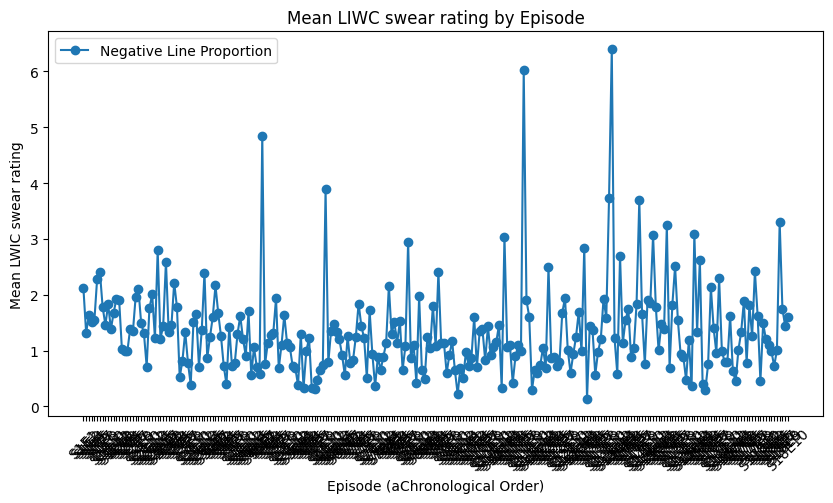

In [4]:
def plot_episodes(metric):
    episode_means = df_liwc.groupby(['Season', 'Episode'])[metric].mean().reset_index()
    episode_means = episode_means.sort_values(by=['Season', 'Episode'])

    # Create a continuous x-axis (indexing episodes chronologically)
    episode_means['x'] = range(len(episode_means))  # Create a sequential x-axis

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(episode_means['x'], episode_means[metric], marker='o', linestyle='-', label="Negative Line Proportion")

    # Customize X-axis labels
    plt.xticks(episode_means['x'], labels=[f"S{s}E{e}" for s, e in zip(episode_means['Season'], episode_means['Episode'])], rotation=45)

    # Labels and Title
    plt.xlabel("Episode (aChronological Order)")
    plt.ylabel(f"Mean LWIC {metric} rating")
    plt.title(f"Mean LIWC {metric} rating by Episode")
    plt.legend()

    plt.show()

plot_episodes("swear")

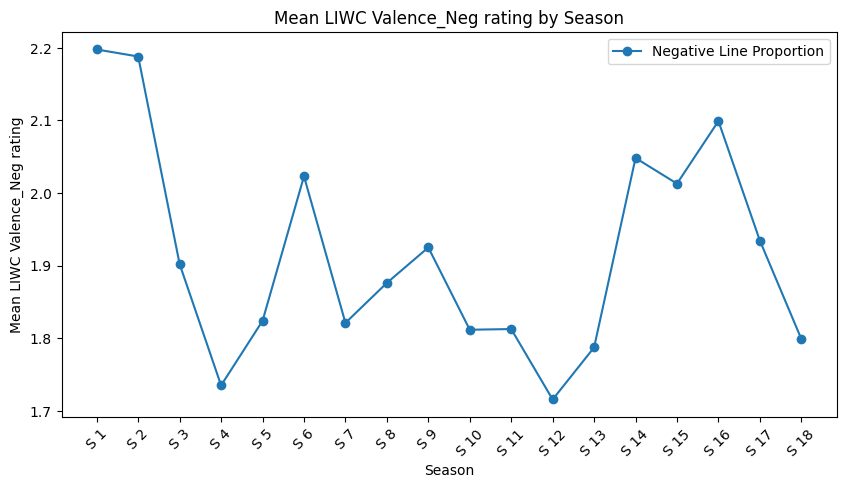

In [23]:
def plot_season(metric):
    season_means = df_liwc.groupby('Season')[metric].mean().reset_index()
    season_means = season_means.sort_values(by=['Season'])

    # Create a continuous x-axis (indexing episodes chronologically)
    season_means['x'] = range(len(season_means))  # Create a sequential x-axis

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(season_means['x'], season_means[metric], marker='o', linestyle='-', label="Negative Line Proportion")

    # Customize X-axis labels
    plt.xticks(season_means['x'], labels=[f"S {s}" for s in season_means['Season']], rotation=45)

    # Labels and Title
    plt.xlabel("Season")
    plt.ylabel(f"Mean LIWC {metric} rating")
    plt.title(f"Mean LIWC {metric} rating by Season")
    plt.legend()

    plt.show()

plot_season("Valence_Neg")
# why did season 6 have more sexual lines

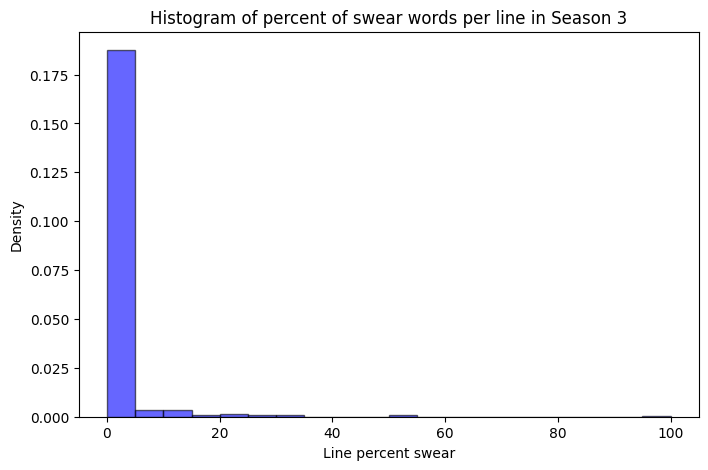

In [27]:
# function to look at distribution of scores within an individual season
def plot_metric_hist(df, metric, season):
    season_data = df[df['Season'] == season]
    
    plt.figure(figsize=(8, 5))
    plt.hist(season_data[metric], bins=20, density=True, alpha=0.6, color='blue', edgecolor='black')
    
    plt.xlabel(f"Line percent {metric}")
    plt.ylabel("Density")
    plt.title(f"Histogram of percent of {metric} words per line in Season {season}")
    
    plt.show()

plot_metric_hist(df_liwc, "swear", 3)

# none of the distributions are normal
# if restricted to only looking at lines about 80 the distrib is more normal

In [23]:
# statistical anova/ test for means
#ANOVA test - data doesn't meet this assumption
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg

def test_all_means(df, metric):
        df['Season'] = df['Season'].astype('category') # df must have season col
        
        # check homoscedascity
        test_var = pg.homoscedasticity(data=df, 
                dv=metric, 
                group="Season").round(2)
        
        same_mean = test_var["equal_var"].iloc[0]
        

        #check normality
        model = ols(f"{metric} ~ Season", data=df).fit()
        res = model.resid
        test_norm = pg.normality(res)
        is_norm = test_norm["normal"].iloc[0]

        # run appropriate test
        if ~is_norm:
                print(pg.kruskal(data=df, 
                        dv=metric, 
                        between='Season'))
                
        elif ~same_mean:
                print(pg.welch_anova(data=df, 
                        dv=metric, 
                        between='Season'))
        else:
                print(pg.anova(data=df, 
                        dv=metric, 
                        between='Season'))

test_all_means(df_liwc, "sexual")

         Source  ddof1           H         p-unc
Kruskal  Season     17  199.055896  4.432051e-33


/var/folders/y3/9kz6d9vd0x33ydn26_b3sfs40000gn/T/ipykernel_4536/2877254209.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  same_mean = test_var["equal_var"][0]
/opt/homebrew/lib/python3.11/site-packages/pingouin/distribution.py:230: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 70878.
  stats = numdata.apply(lambda x: func(x.dropna()), result_type="expand", axis=0).T


In [30]:
# Data is not normally distributed and can't be easily sorted into 0/1 categories: use Mann-Whitney U
def mwu_test(df, metric, s1, s2):
    s1_data = df.loc[df["Season"] == s1, metric]
    s2_data = df.loc[df["Season"] == s2, metric]
    test = pg.mwu(s1_data, s2_data)
    return test["p-val"].iloc[0]

def compare_consecutive_means(df, metric):
    pvals = pd.DataFrame({"s1": [], "s2": [], "pval": []})

    # get mwu tests for every consecutive season pair
    for i in range (1, len(df["Season"].unique())):
        pval = mwu_test(df, metric, i, i+1)
        pvals.loc[len(pvals)] = [i, i+1, pval]

    # apply holm correction
    pvals = pvals.sort_values(by = "pval", ascending = False)
    pvals["rank"] = range(1, len(pvals)+1)
    pvals["holm_pval"] = pvals["pval"] * pvals["rank"]
    pvals["significant"] = pvals["holm_pval"]< 0.05

    return pvals

pvals = compare_consecutive_means(df_liwc, "swear")
pvals

,s1,s2,pval,rank,holm_pval,significant
2,3.0,4.0,8.891314e-01,1,8.891314e-01,False
5,6.0,7.0,8.632174e-01,2,1.726435e+00,False
13,14.0,15.0,8.379705e-01,3,2.513911e+00,False
16,17.0,18.0,6.261056e-01,4,2.504422e+00,False
12,13.0,14.0,5.085027e-01,5,2.542514e+00,False
8,9.0,10.0,2.730059e-01,6,1.638035e+00,False
10,11.0,12.0,1.727720e-01,7,1.209404e+00,False
15,16.0,17.0,1.670329e-01,8,1.336263e+00,False
3,4.0,5.0,1.437333e-01,9,1.293599e+00,False
0,1.0,2.0,5.967594e-02,10,5.967594e-01,False
